In [1]:
!pip install transformers peft torch bitsandbytes accelerate trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
!pip install torchao>=0.16.0

In [3]:
import os
import argparse
import yaml
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, PeftModel

In [4]:
def load_config(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [14]:
import os
from huggingface_hub import snapshot_download
import yaml

# Define the root directory name for the project
project_root_dir_name = "lora_qwen3_poetry"

# Define the absolute target path for the project root, always starting from /content
absolute_target_path = os.path.join("/content", project_root_dir_name)

print(f"目标项目目录: {absolute_target_path}")

# Check if the target project directory exists
if not os.path.exists(absolute_target_path):
    print(f"目录 '{absolute_target_path}' 不存在。正在创建...")
    os.makedirs(absolute_target_path, exist_ok=True)
    print(f"目录 '{absolute_target_path}' 已创建。")
else:
    print(f"目录 '{absolute_target_path}' 已存在。")

# Change to the target project directory
os.chdir(absolute_target_path)
print(f"已将当前工作目录更改为: {os.getcwd()}")

# Define config file path (now relative to the new CWD)
config_file_path = "config.yaml"

# Define default configuration values
default_config = {
    'model_dir': 'models/Qwen3-1.7B',
    'data_path': 'poetry_raw.jsonl',
    'processed_data_path': 'processed_dataset',
    'output_dir': './poetry_lora_output',
    'adapter_dir': './poetry_lora_adapter',
    'max_length': 1024,
    'system_prompt': '你是一个才华横溢的诗人，根据给定的创作背景生成一首诗词。',
    'model_name': 'Qwen/Qwen3-1.7B',
    'lora_r': 8,
    'lora_alpha': 16,
    'lora_dropout': 0.05,
    'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'num_epochs': 1,
    'batch_size': 1,
    'gradient_accumulation_steps': 1,
    'seed': 42
}

# Create config.yaml with default values if it doesn't exist
if not os.path.exists(config_file_path):
    print(f"正在创建默认 config.yaml 文件于 {os.getcwd()}/{config_file_path}...")
    with open(config_file_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(default_config, f)
    print("默认 config.yaml 文件已创建。")
else:
    print(f"config.yaml 文件已存在于 {os.getcwd()}/{config_file_path}。跳过创建。")

# Load the configuration
config = load_config(config_file_path)
print("配置已加载。")

# Download the model from Hugging Face if not already present
model_local_path = config["model_dir"]
if not os.path.exists(model_local_path):
    print(f"正在从 Hugging Face 下载模型 {config['model_name']} 到 {model_local_path}...")
    # Use local_dir_use_symlinks=False to ensure full copy in Colab
    snapshot_download(repo_id=config["model_name"], local_dir=model_local_path, local_dir_use_symlinks=False)
    print("模型下载完成。")
else:
    print(f"模型已存在于 {model_local_path}。跳过下载。")

config

目标项目目录: /content/lora_qwen3_poetry
目录 '/content/lora_qwen3_poetry' 已存在。
已将当前工作目录更改为: /content/lora_qwen3_poetry
config.yaml 文件已存在于 /content/lora_qwen3_poetry/config.yaml。跳过创建。
配置已加载。
正在从 Hugging Face 下载模型 Qwen/Qwen3-1.7B 到 models/Qwen3-1.7B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

模型下载完成。


{'model_dir': 'models/Qwen3-1.7B',
 'data_path': 'poetry_raw.jsonl',
 'processed_data_path': 'processed_dataset',
 'output_dir': './poetry_lora_output',
 'adapter_dir': './poetry_lora_adapter',
 'max_length': 1024,
 'system_prompt': '你是一个才华横溢的诗人，根据给定的创作背景生成一首诗词。',
 'model_name': 'Qwen/Qwen3-1.7B',
 'lora_r': 8,
 'lora_alpha': 16,
 'lora_dropout': 0.05,
 'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
 'num_epochs': 1,
 'batch_size': 1,
 'gradient_accumulation_steps': 4,
 'learning_rate': 0.0002,
 'logging_steps': 1,
 'save_steps': 50,
 'save_total_limit': 2,
 'seed': 42,
 'max_new_tokens': 1000,
 'temperature': 0.7,
 'top_p': 0.9,
 'test_backgrounds': ['背景：隆冬大雪，老友来访，围炉夜话，回忆往昔。', '背景：中秋月夜，游子漂泊异乡，望月思乡。']}

In [15]:
set_seed(config["seed"])

In [16]:
# 检测设备
use_gpu = torch.cuda.is_available()
print(f"GPU 可用: {use_gpu}")

# 加载 tokenizer
tokenizer = AutoTokenizer.from_pretrained(config["model_dir"], trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# 加载模型（根据设备选择量化）
if use_gpu:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )
    model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    fp16 = True
    print("模型加载至 GPU (4bit)")
else:
    model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        device_map="cpu",
        trust_remote_code=True,
        dtype=torch.float32
    )
    fp16 = False
    print("模型加载至 CPU (fp32)，请确保内存充足")

GPU 可用: True


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

模型加载至 GPU (4bit)


In [7]:
model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [18]:
model.config.use_cache = False

# 加载预处理数据集
dataset = load_from_disk(config["processed_data_path"])
print(f"数据集样本数: {len(dataset)}")

数据集样本数: 100


In [19]:
# LoRA 配置
lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=config["lora_r"],
    lora_alpha=config["lora_alpha"],
    lora_dropout=config["lora_dropout"],
    target_modules=config["target_modules"],
    bias="none"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 3,211,264 || all params: 1,723,786,240 || trainable%: 0.1863


In [11]:
!pip install torchao>=0.16.0

In [20]:
# 训练参数
training_args = TrainingArguments(
    output_dir=config["output_dir"],
    num_train_epochs=config["num_epochs"],
    per_device_train_batch_size=config["batch_size"],
    gradient_accumulation_steps=config["gradient_accumulation_steps"],
    learning_rate=config["learning_rate"],
    fp16=fp16,
    logging_steps=config["logging_steps"],
    save_steps=config["save_steps"],
    save_total_limit=config["save_total_limit"],
    remove_unused_columns=False,
    # report_to="tensorboard",
    # TENSORBOARD_LOGGING_DIR="./logs",
    seed=config["seed"],
    dataloader_pin_memory=False if not use_gpu else True,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=data_collator,
)

In [21]:
print("\n开始训练...")
trainer.train()
print("训练完成")


开始训练...


Step,Training Loss
1,4.695482
2,4.555172
3,4.011806
4,3.618471
5,3.320238
6,3.574885
7,3.315048
8,3.305749
9,3.101401
10,2.920661


训练完成


LoRA adapter 已保存至 ./poetry_lora_adapter
Loss 曲线已保存至 training_loss2.png
训练日志已保存至 training_log.txt


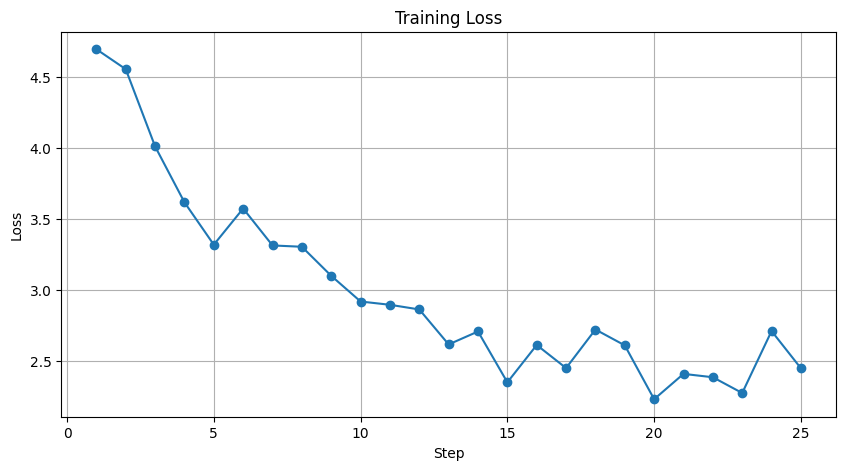

In [22]:
# 保存 LoRA adapter
model.save_pretrained(config["adapter_dir"])
tokenizer.save_pretrained(config["adapter_dir"])
print(f"LoRA adapter 已保存至 {config['adapter_dir']}")

# 绘制并保存 loss 曲线
log_history = trainer.state.log_history
losses = [e["loss"] for e in log_history if "loss" in e]
steps = [e["step"] for e in log_history if "loss" in e]
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.savefig("training_loss2.png")
print("Loss 曲线已保存至 training_loss2.png")

# 写入文本日志
with open("training_log2.txt", "w") as f:
    for s, l in zip(steps, losses):
        f.write(f"Step {s}: loss = {l:.6f}\n")
print("训练日志已保存至 training_log.txt")

In [23]:
# ===== 验证生成 =====
# del model
if use_gpu:
    torch.cuda.empty_cache()

# 重新加载基础模型和 adapter 用于推理
if use_gpu:
    base_model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        device_map="cpu",
        trust_remote_code=True,
        dtype=torch.float32
    )
model = PeftModel.from_pretrained(base_model, config["adapter_dir"])
print("加载训练好的 LoRA 模型用于验证")

generation_config = {
    "max_new_tokens": config["max_new_tokens"],
    "temperature": config["temperature"],
    "top_p": config["top_p"],
    "do_sample": True,
    "eos_token_id": tokenizer.eos_token_id,
    "pad_token_id": tokenizer.pad_token_id,
}

results = []
for bg in config["test_backgrounds"]:
    messages = [
        {"role": "system", "content": config["system_prompt"]},
        {"role": "user", "content": bg}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, **generation_config)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=False)[len(prompt):].strip()
    results.append(f"背景：{bg}\n生成诗词：\n{answer}\n")
    print(f"\n背景：{bg}\n生成诗词：\n{answer}")

with open("generated_poems.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(results))
print("验证结果已保存至 generated_poems.txt")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

加载训练好的 LoRA 模型用于验证

背景：背景：隆冬大雪，老友来访，围炉夜话，回忆往昔。
生成诗词：
<think>assistant
<think>
好的，用户让我根据隆冬大雪、老友来访、围炉夜话、回忆往昔的背景写一首诗词。首先，我需要确定诗的类型和结构。用户可能希望是一首古典诗词，比如七言律诗或绝句，但考虑到背景是回忆和夜话，可能更倾向于古风或律诗。

接下来，分析场景：隆冬、大雪、老友来访、围炉夜话、回忆往昔。这些元素需要融入诗中，营造出温暖的回忆氛围，同时突出冬夜的寒冷和友情的温暖对比。

然后考虑意象的选择。冬夜、雪景、炉火、旧事、友情、岁月等。需要将自然景象与情感结合，比如用“雪”来象征纯洁，用“炉火”象征温暖，用“旧事”表达回忆。

接下来是结构安排。可能先描绘雪景和夜晚的寒冷，再转到回忆，用一些典故或比喻来表达情感。比如“孤舟蓑笠翁”这样的意象，但可能需要调整，因为用户可能希望更贴近友情的回忆。

然后考虑押韵和对仗。七言律诗通常要求平仄和对仗工整，但用户可能更偏向古风，所以可以适当放宽，注重意境和情感表达。

可能需要分几个段落：开头描绘雪夜场景，中间回忆往事，结尾表达情感。比如“雪压千山白”开头，接着“孤灯照客心”转到回忆，再用“旧事如潮水”表达回忆的涌动，最后用“长歌对雪思”收尾，表达感慨。

检查用词是否贴合主题，比如“炉火”是否合适，或者改为“暖炉”更贴切。同时注意避免陈词滥调，用新颖的比喻，比如“雪作梅魂”来比喻雪中的梅花，增添诗意。

最后，通读全诗，确保情感连贯，意境统一，符合用户的需求。可能需要调整用词和结构，使整首诗流畅自然，情感真挚。
</think>

《雪夜忆友》
雪压千山白，孤灯照客心。
寒炉煨冷酒，暖意入幽襟。
旧事如潮水，浮生似梦沉。
相逢重九日，犹记少年时。
雪作梅魂冷，风牵柳意深。
一炉煨酒久，半世梦回寻。
不问浮生事，但将旧事斟。
长歌对雪思，清梦落瑶琴。

赏析：这首作品通过描绘雪夜围炉的温馨场景，抒发了对老友重逢的感慨。诗中“寒炉煨冷酒”与“暖意入幽襟”形成鲜明对比，突出友情的温暖。尾联“长歌对雪思，清梦落瑶琴”则将情感提升到艺术境界，展现出诗人对往事的深情追忆和对当下时光的沉思。<|im_end|>

背景：背景：中秋月夜，游子漂泊异乡，望月思乡。
生成诗词：
<think>
好的，用户让我根据中秋月夜